In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
import os

os.getcwd()


'/home/hadeermoftah/MD_6F'

In [4]:
rmsd_file = "analysis/rmsd/protein_backbone_rmsd.xvg"

with open(rmsd_file, "r") as file:
    for i in range(15):
        print(file.readline().strip())

# This file was created Mon Aug 31 14:11:02 2026
# Created by:
#            :-) GROMACS - gmx rms, 2023.3-Ubuntu_2023.3_1ubuntu3 (-:
#
# Executable:   /usr/bin/gmx
# Data prefix:  /usr
# Working dir:  /home/hadeermoftah/MD_6F
# Command line:
#   gmx rms -s md.tpr -f analysis/trajectory/production_fit.xtc -o analysis/rmsd/protein_backbone_rmsd.xvg -tu ns
# gmx rms is part of G R O M A C S:
#
# GROup of MAchos and Cynical Suckers
#
@    title "RMSD"
@    xaxis  label "Time (ns)"


In [5]:
with open(rmsd_file, "r") as file:
    rmsd_data = np.loadtxt(
        line for line in file
        if not line.startswith(("#", "@"))
    )

rmsd_data.shape

(2001, 2)

In [6]:
time = rmsd_data[:, 0]
rmsd = rmsd_data[:, 1]

print("First time:", time[0], "ns")
print("Last time:", time[-1], "ns")
print("Number of frames:", len(time))

print("First RMSD:", rmsd[0], "nm")
print("Last RMSD:", rmsd[-1], "nm")

First time: 0.0 ns
Last time: 20.0 ns
Number of frames: 2001
First RMSD: 0.0005003 nm
Last RMSD: 0.1895744 nm


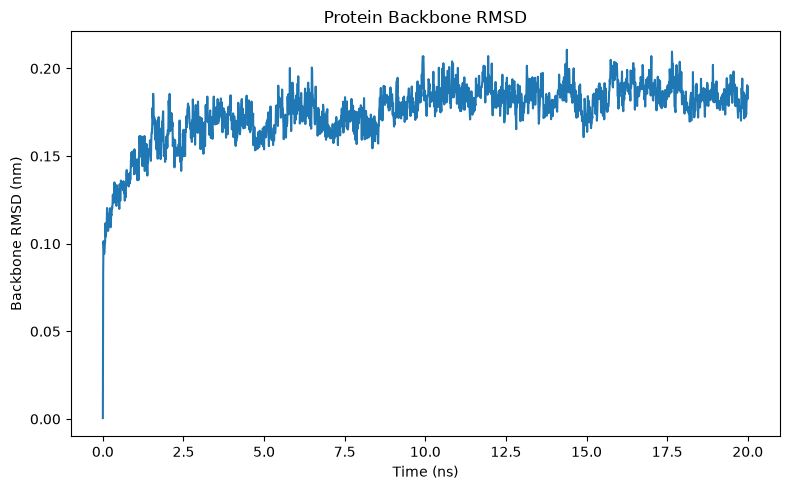

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(time, rmsd)

plt.xlabel("Time (ns)")
plt.ylabel("Backbone RMSD (nm)")
plt.title("Protein Backbone RMSD")

plt.tight_layout()
plt.show()

In [8]:
print("Overall mean RMSD:", np.mean(rmsd), "nm")
print("Overall standard deviation:", np.std(rmsd), "nm")
print("Minimum RMSD:", np.min(rmsd), "nm")
print("Maximum RMSD:", np.max(rmsd), "nm")

Overall mean RMSD: 0.17515073413293356 nm
Overall standard deviation: 0.016802952710847516 nm
Minimum RMSD: 0.0005003 nm
Maximum RMSD: 0.2106754 nm


In [9]:
windows = [(2, 5), (5, 10), (10, 15), (15, 20)]

for start, end in windows:
    mask = (time >= start) & (time < end)
    
    mean_rmsd = np.mean(rmsd[mask])
    std_rmsd = np.std(rmsd[mask])
    
    print(
        f"{start}-{end} ns: "
        f"Mean = {mean_rmsd:.4f} nm, "
        f"SD = {std_rmsd:.4f} nm"
    )

2-5 ns: Mean = 0.1672 nm, SD = 0.0087 nm
5-10 ns: Mean = 0.1742 nm, SD = 0.0092 nm
10-15 ns: Mean = 0.1844 nm, SD = 0.0075 nm
15-20 ns: Mean = 0.1854 nm, SD = 0.0075 nm


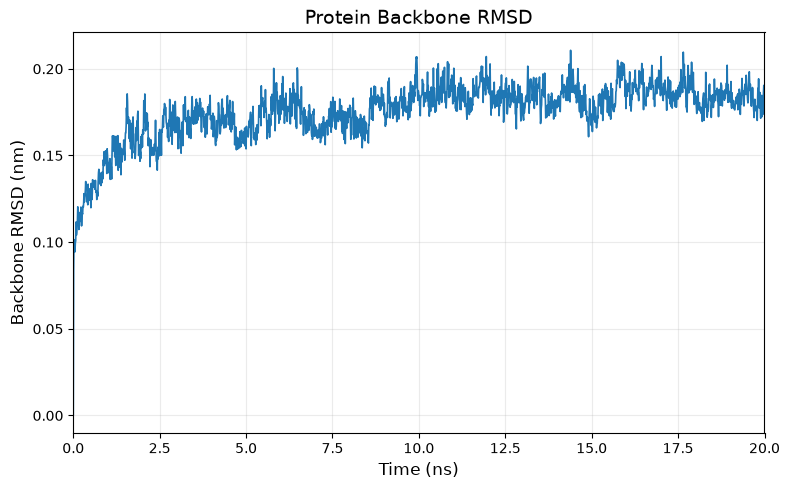

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(time, rmsd, linewidth=1.2)

plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("Backbone RMSD (nm)", fontsize=12)
plt.title("Protein Backbone RMSD", fontsize=14)

plt.xlim(0, 20)
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "results/figures/protein_backbone_rmsd.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
import os

os.path.exists("results/figures/protein_backbone_rmsd.png")

True

In [12]:
ligand_rmsd_file = "analysis/rmsd/ligand_rmsd.xvg"

with open(ligand_rmsd_file, "r") as file:
    ligand_data = np.loadtxt(
        line for line in file
        if not line.startswith(("#", "@"))
    )

ligand_data.shape

(2001, 2)

In [13]:
ligand_time = ligand_data[:, 0]
ligand_rmsd = ligand_data[:, 1]

print("First time:", ligand_time[0], "ns")
print("Last time:", ligand_time[-1], "ns")
print("Number of frames:", len(ligand_time))

print("First Ligand RMSD:", ligand_rmsd[0], "nm")
print("Last Ligand RMSD:", ligand_rmsd[-1], "nm")

First time: 0.0 ns
Last time: 20.0 ns
Number of frames: 2001
First Ligand RMSD: 0.000478 nm
Last Ligand RMSD: 0.5935745 nm


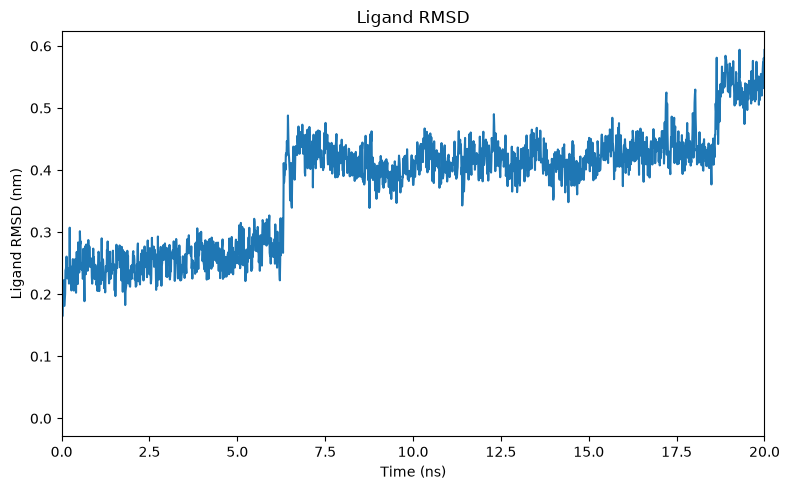

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(ligand_time, ligand_rmsd)

plt.xlabel("Time (ns)")
plt.ylabel("Ligand RMSD (nm)")
plt.title("Ligand RMSD")

plt.xlim(0, 20)
plt.tight_layout()
plt.show()

In [15]:
windows = [(0, 5), (5, 10), (10, 15), (15, 20)]

for start, end in windows:
    mask = (ligand_time >= start) & (ligand_time < end)

    mean_rmsd = np.mean(ligand_rmsd[mask])
    std_rmsd = np.std(ligand_rmsd[mask])

    print(
        f"{start}-{end} ns: "
        f"Mean = {mean_rmsd:.4f} nm, "
        f"SD = {std_rmsd:.4f} nm"
    )

0-5 ns: Mean = 0.2496 nm, SD = 0.0255 nm
5-10 ns: Mean = 0.3773 nm, SD = 0.0653 nm
10-15 ns: Mean = 0.4144 nm, SD = 0.0227 nm
15-20 ns: Mean = 0.4603 nm, SD = 0.0506 nm


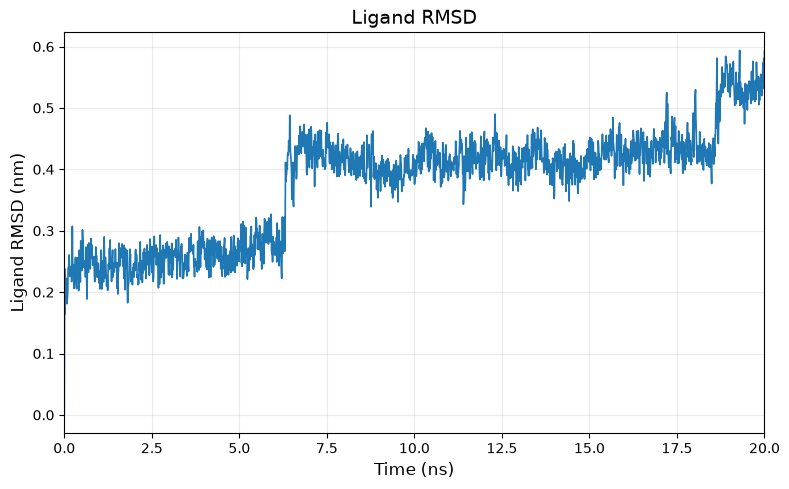

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(ligand_time, ligand_rmsd, linewidth=1.2)

plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("Ligand RMSD (nm)", fontsize=12)
plt.title("Ligand RMSD", fontsize=14)

plt.xlim(0, 20)
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "results/figures/ligand_rmsd.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
hbond_file = "analysis/hbonds/protein_6F_hbonds.xvg"

with open(hbond_file, "r") as file:
    hbond_data = np.loadtxt(
        line for line in file
        if not line.startswith(("#", "@"))
    )

hbond_data.shape

(2001, 3)

In [18]:
with open(hbond_file, "r") as file:
    for line in file:
        if line.startswith("@"):
            print(line.strip())

@    title "Hydrogen Bonds"
@    xaxis  label "Time (ps)"
@    yaxis  label "Number"
@TYPE xy
@ view 0.15, 0.15, 0.75, 0.85
@ legend on
@ legend box on
@ legend loctype view
@ legend 0.78, 0.8
@ legend length 2
@ s0 legend "Hydrogen bonds"
@ s1 legend "Pairs within 0.35 nm"


In [19]:
hbond_time_ps = hbond_data[:, 0]
hbond_time_ns = hbond_time_ps / 1000

hbonds = hbond_data[:, 1]
pairs_035 = hbond_data[:, 2]

print("First time:", hbond_time_ns[0], "ns")
print("Last time:", hbond_time_ns[-1], "ns")
print("Number of frames:", len(hbond_time_ns))

print("Mean H-bonds:", np.mean(hbonds))
print("SD:", np.std(hbonds))
print("Minimum:", np.min(hbonds))
print("Maximum:", np.max(hbonds))

First time: 0.0 ns
Last time: 20.0 ns
Number of frames: 2001
Mean H-bonds: 1.5497251374312844
SD: 1.1819275350307066
Minimum: 0.0
Maximum: 5.0


In [20]:
windows = [(0,5), (5,10), (10,15), (15,20)]

for start, end in windows:
    mask = (hbond_time_ns >= start) & (hbond_time_ns < end)

    print(
        f"{start}-{end} ns: "
        f"Mean = {np.mean(hbonds[mask]):.2f}, "
        f"SD = {np.std(hbonds[mask]):.2f}"
    )

0-5 ns: Mean = 2.62, SD = 0.70
5-10 ns: Mean = 1.54, SD = 1.43
10-15 ns: Mean = 1.12, SD = 0.86
15-20 ns: Mean = 0.93, SD = 0.77


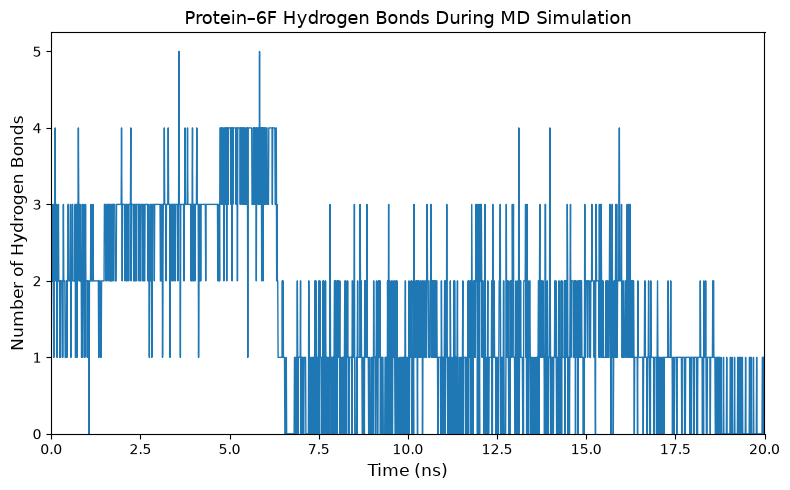

In [21]:
plt.figure(figsize=(8,5))

plt.plot(hbond_time_ns, hbonds, linewidth=1)

plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("Number of Hydrogen Bonds", fontsize=12)
plt.title("Protein–6F Hydrogen Bonds During MD Simulation", fontsize=13)

plt.xlim(0,20)
plt.ylim(bottom=0)

plt.tight_layout()

plt.savefig(
    "results/figures/protein_6F_hbonds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

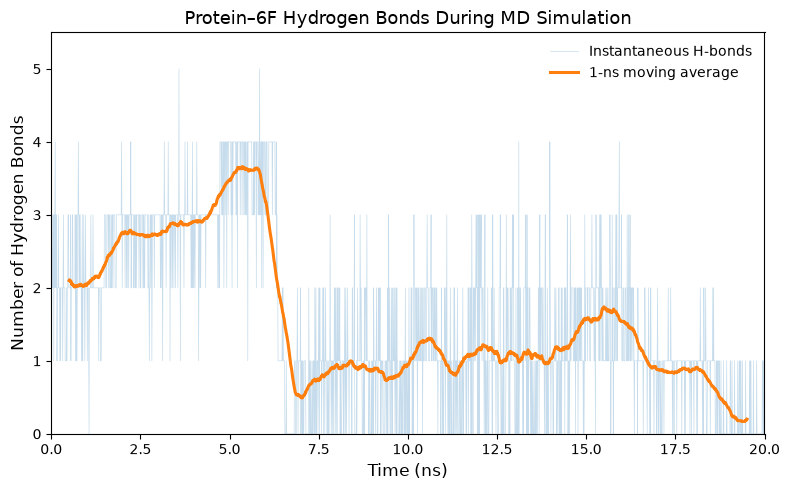

In [22]:
hbond_series = pd.Series(hbonds)

# 100 frames = 1 ns moving average
hbond_smooth = hbond_series.rolling(
    window=100,
    center=True
).mean()

plt.figure(figsize=(8,5))

# Raw H-bond counts
plt.plot(
    hbond_time_ns,
    hbonds,
    linewidth=0.5,
    alpha=0.25,
    label="Instantaneous H-bonds"
)

# 1-ns moving average
plt.plot(
    hbond_time_ns,
    hbond_smooth,
    linewidth=2.2,
    label="1-ns moving average"
)

plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("Number of Hydrogen Bonds", fontsize=12)
plt.title("Protein–6F Hydrogen Bonds During MD Simulation", fontsize=13)

plt.xlim(0,20)
plt.ylim(0,5.5)

plt.legend(frameon=False)
plt.tight_layout()

plt.savefig(
    "results/figures/protein_6F_hbonds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
rmsf_file = "analysis/rmsf/protein_ca_rmsf.xvg"

with open(rmsf_file, "r") as file:
    rmsf_data = np.loadtxt(
        line for line in file
        if not line.startswith(("#", "@"))
    )

print("Shape:", rmsf_data.shape)
print(rmsf_data[:5])

Shape: (530, 2)
[[4.     0.5742]
 [5.     0.3953]
 [6.     0.1426]
 [7.     0.1328]
 [8.     0.0734]]


In [24]:
residue = rmsf_data[:, 0].astype(int)
rmsf = rmsf_data[:, 1]

print("Mean RMSF:", np.mean(rmsf), "nm")
print("SD:", np.std(rmsf), "nm")
print("Minimum:", np.min(rmsf), "nm")
print("Maximum:", np.max(rmsf), "nm")

# Top 10 residues with highest RMSF
top_indices = np.argsort(rmsf)[-10:][::-1]

print("\nTop 10 most flexible residues:")
for i in top_indices:
    print(f"Residue {residue[i]}: {rmsf[i]:.4f} nm")

Mean RMSF: 0.07900169811320755 nm
SD: 0.04349285971482003 nm
Minimum: 0.0366 nm
Maximum: 0.5742 nm

Top 10 most flexible residues:
Residue 4: 0.5742 nm
Residue 5: 0.3953 nm
Residue 542: 0.3217 nm
Residue 541: 0.2386 nm
Residue 306: 0.2269 nm
Residue 305: 0.2136 nm
Residue 79: 0.2056 nm
Residue 540: 0.2001 nm
Residue 81: 0.1984 nm
Residue 307: 0.1779 nm


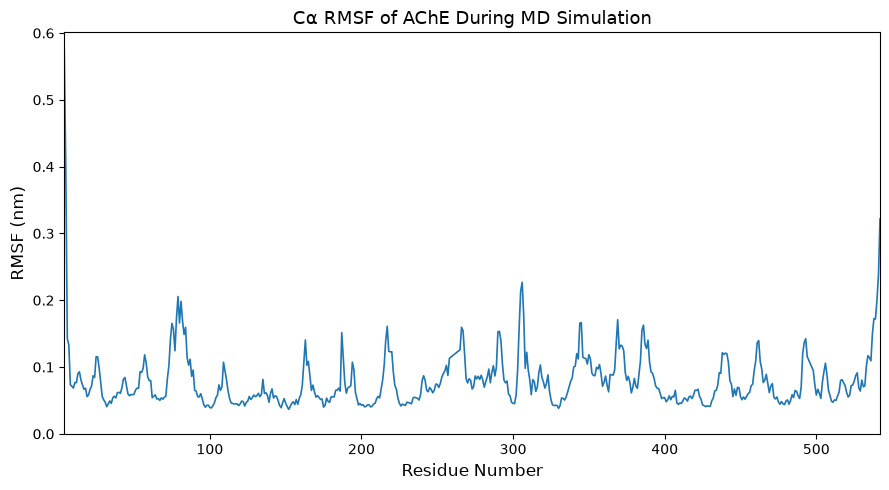

In [25]:
plt.figure(figsize=(9,5))

plt.plot(
    residue,
    rmsf,
    linewidth=1.2
)

plt.xlabel("Residue Number", fontsize=12)
plt.ylabel("RMSF (nm)", fontsize=12)
plt.title("Cα RMSF of AChE During MD Simulation", fontsize=13)

plt.xlim(residue.min(), residue.max())
plt.ylim(bottom=0)

plt.tight_layout()

plt.savefig(
    "results/figures/protein_ca_rmsf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
rg_file = "analysis/rg/protein_rg.xvg"

with open(rg_file, "r") as file:
    rg_data = np.loadtxt(
        line for line in file
        if not line.startswith(("#", "@"))
    )

print("Shape:", rg_data.shape)
print(rg_data[:5])

Shape: (2001, 5)
[[ 0.       2.24048  1.91081  1.83733  1.73567]
 [10.       2.26411  1.92428  1.85616  1.76187]
 [20.       2.28118  1.93682  1.86984  1.77762]
 [30.       2.27788  1.93204  1.86974  1.77447]
 [40.       2.27833  1.93701  1.8708   1.76909]]


In [27]:
rg_time_ps = rg_data[:, 0]
rg_time_ns = rg_time_ps / 1000

rg = rg_data[:, 1]

print("First time:", rg_time_ns[0], "ns")
print("Last time:", rg_time_ns[-1], "ns")
print("Number of frames:", len(rg_time_ns))

print("Mean Rg:", np.mean(rg), "nm")
print("SD:", np.std(rg), "nm")
print("Minimum:", np.min(rg), "nm")
print("Maximum:", np.max(rg), "nm")

First time: 0.0 ns
Last time: 20.0 ns
Number of frames: 2001
Mean Rg: 2.312521484257871 nm
SD: 0.00878111835281327 nm
Minimum: 2.24048 nm
Maximum: 2.33571 nm


In [28]:
windows = [(0,5), (5,10), (10,15), (15,20)]

for start, end in windows:
    mask = (rg_time_ns >= start) & (rg_time_ns < end)

    print(
        f"{start}-{end} ns: "
        f"Mean = {np.mean(rg[mask]):.4f} nm, "
        f"SD = {np.std(rg[mask]):.4f} nm"
    )

0-5 ns: Mean = 2.3020 nm, SD = 0.0070 nm
5-10 ns: Mean = 2.3118 nm, SD = 0.0055 nm
10-15 ns: Mean = 2.3183 nm, SD = 0.0053 nm
15-20 ns: Mean = 2.3179 nm, SD = 0.0054 nm


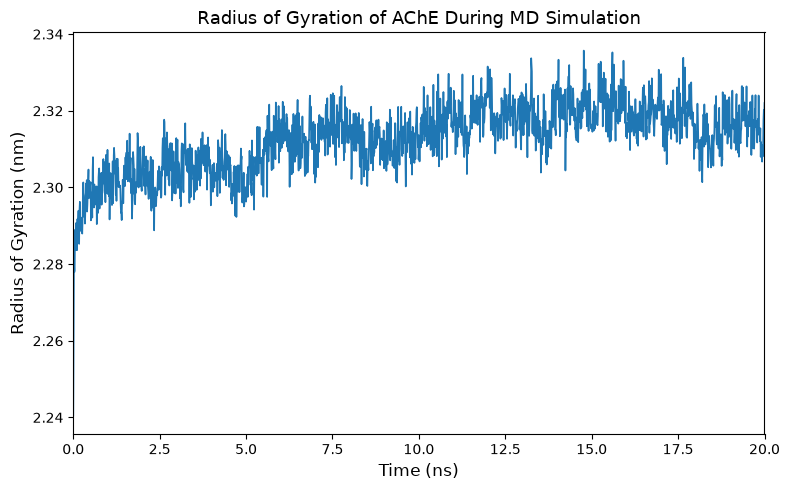

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    rg_time_ns,
    rg,
    linewidth=1.2
)

plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("Radius of Gyration (nm)", fontsize=12)
plt.title("Radius of Gyration of AChE During MD Simulation", fontsize=13)

plt.xlim(0,20)

plt.tight_layout()

plt.savefig(
    "results/figures/protein_rg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
mindist_file = "analysis/diagnostics/protein_6F_mindist.xvg"
contacts_file = "analysis/diagnostics/protein_6F_contacts.xvg"

with open(mindist_file, "r") as file:
    mindist_data = np.loadtxt(
        line for line in file
        if not line.startswith(("#", "@"))
    )

with open(contacts_file, "r") as file:
    contacts_data = np.loadtxt(
        line for line in file
        if not line.startswith(("#", "@"))
    )

print("Mindist shape:", mindist_data.shape)
print(mindist_data[:5])

print("\nContacts shape:", contacts_data.shape)
print(contacts_data[:5])

Mindist shape: (2001, 2)
[[ 0.         0.1643746]
 [10.         0.1455647]
 [20.         0.1715165]
 [30.         0.1283236]
 [40.         0.1118434]]

Contacts shape: (2001, 2)
[[  0. 748.]
 [ 10. 710.]
 [ 20. 626.]
 [ 30. 701.]
 [ 40. 721.]]


In [31]:
contact_time_ns = contacts_data[:, 0] / 1000
contacts = contacts_data[:, 1]

mindist_time_ns = mindist_data[:, 0] / 1000
mindist = mindist_data[:, 1]

print("Minimum-distance analysis")
print("Mean:", np.mean(mindist), "nm")
print("SD:", np.std(mindist), "nm")
print("Minimum:", np.min(mindist), "nm")
print("Maximum:", np.max(mindist), "nm")

print("\nContact analysis")
print("Mean contacts:", np.mean(contacts))
print("SD:", np.std(contacts))
print("Minimum contacts:", np.min(contacts))
print("Maximum contacts:", np.max(contacts))

Minimum-distance analysis
Mean: 0.1693409847876062 nm
SD: 0.024133246312370935 nm
Minimum: 0.08362437 nm
Maximum: 0.2382834 nm

Contact analysis
Mean contacts: 609.3498250874562
SD: 47.546810740717234
Minimum contacts: 472.0
Maximum contacts: 793.0


In [32]:
windows = [(0,5), (5,10), (10,15), (15,20)]

for start, end in windows:
    mask = (contact_time_ns >= start) & (contact_time_ns < end)

    print(
        f"{start}-{end} ns: "
        f"Contacts = {np.mean(contacts[mask]):.1f} ± {np.std(contacts[mask]):.1f}, "
        f"Min distance = {np.mean(mindist[mask]):.3f} ± {np.std(mindist[mask]):.3f} nm"
    )

0-5 ns: Contacts = 648.6 ± 44.0, Min distance = 0.170 ± 0.017 nm
5-10 ns: Contacts = 608.1 ± 38.8, Min distance = 0.167 ± 0.024 nm
10-15 ns: Contacts = 602.6 ± 40.6, Min distance = 0.167 ± 0.027 nm
15-20 ns: Contacts = 578.2 ± 37.3, Min distance = 0.174 ± 0.027 nm


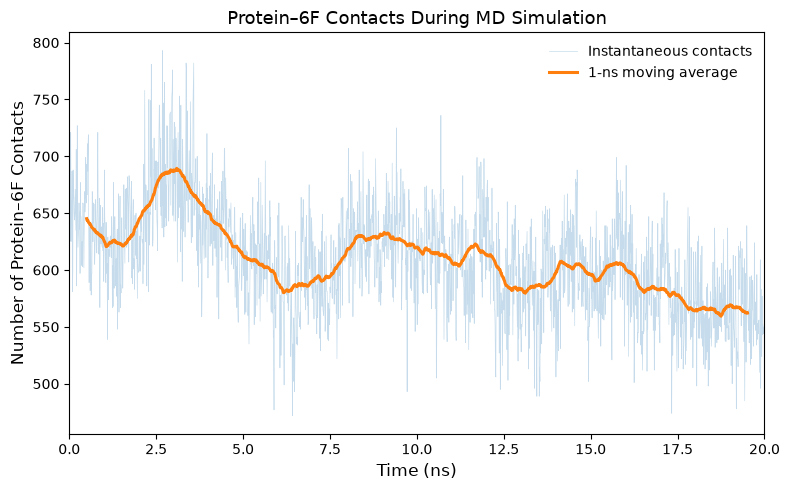

In [33]:
contact_smooth = pd.Series(contacts).rolling(
    window=100,
    center=True
).mean()

plt.figure(figsize=(8,5))

plt.plot(
    contact_time_ns,
    contacts,
    linewidth=0.5,
    alpha=0.25,
    label="Instantaneous contacts"
)

plt.plot(
    contact_time_ns,
    contact_smooth,
    linewidth=2.2,
    label="1-ns moving average"
)

plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("Number of Protein–6F Contacts", fontsize=12)
plt.title("Protein–6F Contacts During MD Simulation", fontsize=13)

plt.xlim(0,20)
plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "results/figures/protein_6F_contacts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
ligand_heavy_file = "analysis/rmsd/ligand_heavy_rmsd.xvg"

with open(ligand_heavy_file, "r") as file:
    ligand_heavy_data = np.loadtxt(
        line for line in file
        if not line.startswith(("#", "@"))
    )

print("Shape:", ligand_heavy_data.shape)
print(ligand_heavy_data[:5])

Shape: (2001, 2)
[[0.        0.0004775]
 [0.01      0.2364262]
 [0.02      0.1619482]
 [0.03      0.1858933]
 [0.04      0.1942489]]


In [35]:
ligand_heavy_time = ligand_heavy_data[:, 0]
ligand_heavy_rmsd = ligand_heavy_data[:, 1]

print("First time:", ligand_heavy_time[0], "ns")
print("Last time:", ligand_heavy_time[-1], "ns")
print("Number of frames:", len(ligand_heavy_time))

print("First RMSD:", ligand_heavy_rmsd[0], "nm")
print("Last RMSD:", ligand_heavy_rmsd[-1], "nm")

print("Mean RMSD:", ligand_heavy_rmsd.mean(), "nm")
print("SD:", ligand_heavy_rmsd.std(), "nm")
print("Minimum:", ligand_heavy_rmsd.min(), "nm")
print("Maximum:", ligand_heavy_rmsd.max(), "nm")

First time: 0.0 ns
Last time: 20.0 ns
Number of frames: 2001
First RMSD: 0.0004775 nm
Last RMSD: 0.5935377 nm
Mean RMSD: 0.3759397609695152 nm
SD: 0.09143623864073827 nm
Minimum: 0.0004775 nm
Maximum: 0.5950446 nm


In [36]:
windows = [(0,5), (5,10), (10,15), (15,20)]

for start, end in windows:
    if end == 20:
        mask = (ligand_heavy_time >= start) & (ligand_heavy_time <= end)
    else:
        mask = (ligand_heavy_time >= start) & (ligand_heavy_time < end)

    values = ligand_heavy_rmsd[mask]

    print(
        f"{start}-{end} ns: "
        f"Mean = {values.mean():.4f} nm, "
        f"SD = {values.std():.4f} nm"
    )

0-5 ns: Mean = 0.2481 nm, SD = 0.0255 nm
5-10 ns: Mean = 0.3779 nm, SD = 0.0663 nm
10-15 ns: Mean = 0.4158 nm, SD = 0.0228 nm
15-20 ns: Mean = 0.4618 nm, SD = 0.0505 nm


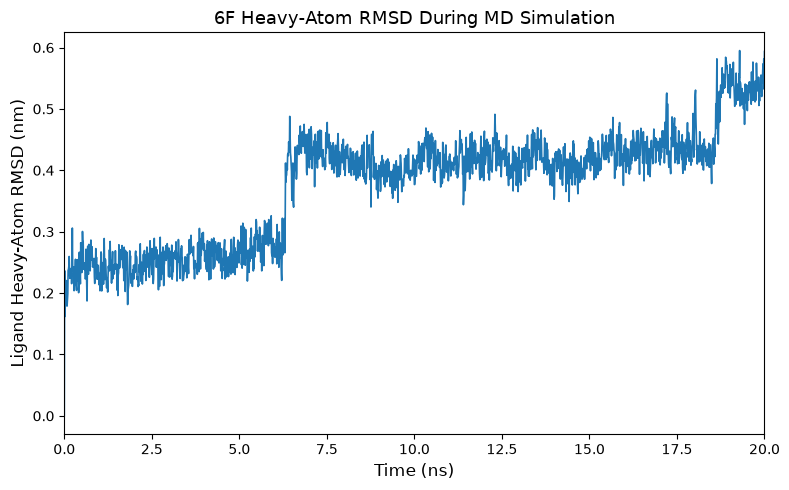

In [37]:
plt.figure(figsize=(8,5))

plt.plot(
    ligand_heavy_time,
    ligand_heavy_rmsd,
    linewidth=1.2
)

plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("Ligand Heavy-Atom RMSD (nm)", fontsize=12)
plt.title("6F Heavy-Atom RMSD During MD Simulation", fontsize=13)

plt.xlim(0,20)

plt.tight_layout()

plt.savefig(
    "results/figures/ligand_heavy_atom_rmsd.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
heavy_contacts_file = "analysis/diagnostics/protein_6F_heavy_contacts.xvg"
heavy_mindist_file = "analysis/diagnostics/protein_6F_heavy_mindist.xvg"

with open(heavy_contacts_file, "r") as file:
    heavy_contacts_data = np.loadtxt(
        line for line in file
        if not line.startswith(("#", "@"))
    )

with open(heavy_mindist_file, "r") as file:
    heavy_mindist_data = np.loadtxt(
        line for line in file
        if not line.startswith(("#", "@"))
    )

print("Heavy contacts shape:", heavy_contacts_data.shape)
print(heavy_contacts_data[:5])

print("\nHeavy mindist shape:", heavy_mindist_data.shape)
print(heavy_mindist_data[:5])

Heavy contacts shape: (2001, 2)
[[  0. 217.]
 [ 10. 185.]
 [ 20. 158.]
 [ 30. 179.]
 [ 40. 192.]]

Heavy mindist shape: (2001, 2)
[[ 0.         0.2814408]
 [10.         0.2659963]
 [20.         0.281174 ]
 [30.         0.2706824]
 [40.         0.262368 ]]


In [39]:
heavy_contact_time_ns = heavy_contacts_data[:, 0] / 1000
heavy_contacts = heavy_contacts_data[:, 1]

heavy_mindist_time_ns = heavy_mindist_data[:, 0] / 1000
heavy_mindist = heavy_mindist_data[:, 1]

print("Mean heavy-atom contacts:", heavy_contacts.mean())
print("SD:", heavy_contacts.std())
print("Minimum contacts:", heavy_contacts.min())
print("Maximum contacts:", heavy_contacts.max())

print("\nMean minimum distance:", heavy_mindist.mean(), "nm")
print("SD:", heavy_mindist.std(), "nm")
print("Minimum distance:", heavy_mindist.min(), "nm")
print("Maximum distance:", heavy_mindist.max(), "nm")

print("\nWindow analysis:")

windows = [(0,5), (5,10), (10,15), (15,20)]

for start, end in windows:
    if end == 20:
        mask = (
            (heavy_contact_time_ns >= start) &
            (heavy_contact_time_ns <= end)
        )
    else:
        mask = (
            (heavy_contact_time_ns >= start) &
            (heavy_contact_time_ns < end)
        )

    print(
        f"{start}-{end} ns: "
        f"Contacts = {heavy_contacts[mask].mean():.1f} ± "
        f"{heavy_contacts[mask].std():.1f}, "
        f"Min distance = {heavy_mindist[mask].mean():.3f} ± "
        f"{heavy_mindist[mask].std():.3f} nm"
    )

Mean heavy-atom contacts: 160.62518740629685
SD: 19.017429215600515
Minimum contacts: 98.0
Maximum contacts: 227.0

Mean minimum distance: 0.2896345049475262 nm
SD: 0.018661957958673706 nm
Minimum distance: 0.2436166 nm
Maximum distance: 0.3353997 nm

Window analysis:
0-5 ns: Contacts = 177.0 ± 14.7, Min distance = 0.270 ± 0.010 nm
5-10 ns: Contacts = 163.7 ± 15.5, Min distance = 0.291 ± 0.019 nm
10-15 ns: Contacts = 157.2 ± 15.9, Min distance = 0.297 ± 0.015 nm
15-20 ns: Contacts = 144.6 ± 13.8, Min distance = 0.300 ± 0.014 nm


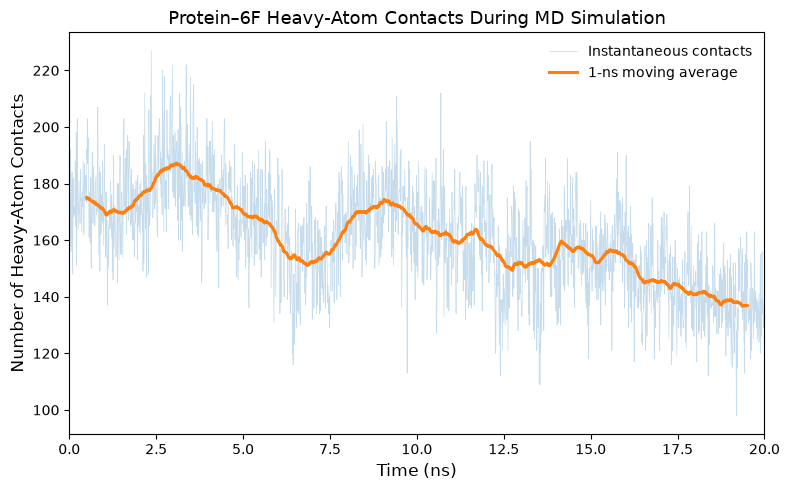

In [40]:
heavy_contact_smooth = pd.Series(heavy_contacts).rolling(
    window=100,
    center=True
).mean()

plt.figure(figsize=(8,5))

plt.plot(
    heavy_contact_time_ns,
    heavy_contacts,
    linewidth=0.5,
    alpha=0.25,
    label="Instantaneous contacts"
)

plt.plot(
    heavy_contact_time_ns,
    heavy_contact_smooth,
    linewidth=2.2,
    label="1-ns moving average"
)

plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("Number of Heavy-Atom Contacts", fontsize=12)
plt.title("Protein–6F Heavy-Atom Contacts During MD Simulation", fontsize=13)

plt.xlim(0,20)
plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "results/figures/protein_6F_heavy_contacts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
import numpy as np

pdb_file = "analysis/trajectory/snapshot_5ns.pdb"

# Aromatic rings of 6F
ligand_rings = {
    "6F_ring_A": ["C16", "C18", "C20", "C22", "C23", "C25"],
    "6F_ring_B": ["C1", "C27", "C28", "C30", "C32", "C34"],
    "6F_ring_C": ["C38", "C39", "C41", "C43", "C44", "C46"],
}

# Standard aromatic ring atoms in amino acids
residue_ring_atoms = {
    "PHE": ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"],
    "TYR": ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"],
    "HIS": ["CG", "ND1", "CD2", "CE1", "NE2"],
    
    # six-membered benzene portion of Trp
    "TRP": ["CD2", "CE2", "CE3", "CZ2", "CZ3", "CH2"],
}

# Candidates found around 6F at 5 ns
candidate_residues = [
    ("TRP", 86),
    ("TYR", 119),
    ("TYR", 124),
    ("TYR", 133),
    ("PHE", 297),
    ("TYR", 337),
    ("PHE", 338),
    ("TYR", 341),
    ("TRP", 439),
    ("HIS", 447),
    ("TYR", 449),
]

In [42]:
def read_pdb_atoms(pdb_file):
    atoms = []

    with open(pdb_file, "r") as f:
        for line in f:
            if line.startswith(("ATOM", "HETATM")):
                atom_name = line[12:16].strip()
                resname = line[17:20].strip()
                chain = line[21].strip()

                try:
                    resid = int(line[22:26])
                except ValueError:
                    continue

                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])

                atoms.append({
                    "atom": atom_name,
                    "resname": resname,
                    "chain": chain,
                    "resid": resid,
                    "coord": np.array([x, y, z])
                })

    return atoms


def get_ring_coords(atoms, resname, resid, atom_names):
    coords = []

    for atom in atoms:
        if (
            atom["resname"] == resname
            and atom["resid"] == resid
            and atom["atom"] in atom_names
        ):
            coords.append(atom["coord"])

    return np.array(coords)


def get_ligand_ring_coords(atoms, atom_names):
    coords = []

    for atom in atoms:
        if (
            atom["resname"] == "6f_"
            and atom["atom"] in atom_names
        ):
            coords.append(atom["coord"])

    return np.array(coords)


def ring_centroid(coords):
    return coords.mean(axis=0)


def ring_normal(coords):
    centered = coords - coords.mean(axis=0)

    _, _, vh = np.linalg.svd(centered)

    normal = vh[-1]

    return normal / np.linalg.norm(normal)


def plane_angle(normal1, normal2):
    cos_angle = np.clip(
        abs(np.dot(normal1, normal2)),
        -1.0,
        1.0
    )

    return np.degrees(np.arccos(cos_angle))


atoms = read_pdb_atoms(pdb_file)

results = []

for lig_name, lig_atom_names in ligand_rings.items():

    lig_coords = get_ligand_ring_coords(
        atoms,
        lig_atom_names
    )

    if len(lig_coords) != len(lig_atom_names):
        print(
            f"Warning: {lig_name} has "
            f"{len(lig_coords)} atoms"
        )
        continue

    lig_centroid = ring_centroid(lig_coords)
    lig_normal = ring_normal(lig_coords)

    for resname, resid in candidate_residues:

        res_atom_names = residue_ring_atoms[resname]

        res_coords = get_ring_coords(
            atoms,
            resname,
            resid,
            res_atom_names
        )

        if len(res_coords) != len(res_atom_names):
            continue

        res_centroid = ring_centroid(res_coords)
        res_normal = ring_normal(res_coords)

        distance = np.linalg.norm(
            lig_centroid - res_centroid
        )

        angle = plane_angle(
            lig_normal,
            res_normal
        )

        results.append([
            lig_name,
            f"{resname}{resid}",
            distance,
            angle
        ])


results_df = pd.DataFrame(
    results,
    columns=[
        "Ligand ring",
        "Residue",
        "Centroid distance (Å)",
        "Plane angle (°)"
    ]
)

results_df = results_df.sort_values(
    "Centroid distance (Å)"
)

results_df

,Ligand ring,Residue,Centroid distance (Å),Plane angle (°)
0,6F_ring_A,TRP86,4.628560,32.203232
17,6F_ring_B,PHE338,4.709580,53.405126
22,6F_ring_C,TRP86,5.213043,67.819912
18,6F_ring_B,TYR341,5.666026,62.835458
15,6F_ring_B,PHE297,6.123469,28.381294
7,6F_ring_A,TYR341,6.519714,80.643653
13,6F_ring_B,TYR124,6.711297,76.797680
16,6F_ring_B,TYR337,6.777020,79.258927
5,6F_ring_A,TYR337,7.153340,55.827969
20,6F_ring_B,HIS447,7.220517,44.877102


In [44]:
import MDAnalysis as mda
print(mda.__version__)

2.10.0


In [45]:
u = mda.Universe(
    "md.tpr",
    "analysis/trajectory/production_fit.xtc"
)

print("Number of atoms:", u.atoms.n_atoms)
print("Number of frames:", len(u.trajectory))

print("First frame time:", u.trajectory[0].time, "ps")
print("Last frame time:", u.trajectory[-1].time, "ps")

Number of atoms: 93987
Number of frames: 2001
First frame time: 0.0 ps
Last frame time: 20000.0 ps


In [46]:
lig_ring_A = u.select_atoms(
    "resname 6f_ and name C16 C18 C20 C22 C23 C25"
)

trp86_ring = u.select_atoms(
    "protein and resid 86 and name CD2 CE2 CE3 CZ2 CZ3 CH2"
)

print("6F Ring A:")
print("Number of atoms:", lig_ring_A.n_atoms)
print("Names:", lig_ring_A.names)
print("Resname:", lig_ring_A.resnames)
print("Resid:", lig_ring_A.resids)

print("\nTRP86 benzene ring:")
print("Number of atoms:", trp86_ring.n_atoms)
print("Names:", trp86_ring.names)
print("Resname:", trp86_ring.resnames)
print("Resid:", trp86_ring.resids)

6F Ring A:
Number of atoms: 6
Names: ['C16' 'C18' 'C20' 'C22' 'C23' 'C25']
Resname: ['6f_' '6f_' '6f_' '6f_' '6f_' '6f_']
Resid: [531 531 531 531 531 531]

TRP86 benzene ring:
Number of atoms: 0
Names: []
Resname: []
Resid: []


In [47]:
trp_residues = u.select_atoms("protein and resname TRP").residues

for res in trp_residues:
    print(res.resname, res.resid)

TRP 53
TRP 83
TRP 99
TRP 114
TRP 179
TRP 233
TRP 277
TRP 376
TRP 430
TRP 433
TRP 471
TRP 488
TRP 520


In [48]:
# Go to the 5 ns frame
u.trajectory[500]   # 500 × 10 ps = 5000 ps = 5 ns

lig_centroid = lig_ring_A.positions.mean(axis=0)

trp_mapping = []

for res in u.select_atoms("protein and resname TRP").residues:

    ring = res.atoms.select_atoms(
        "name CD2 CE2 CE3 CZ2 CZ3 CH2"
    )

    if ring.n_atoms == 6:
        trp_centroid = ring.positions.mean(axis=0)

        distance = np.linalg.norm(
            lig_centroid - trp_centroid
        )

        trp_mapping.append([
            res.resid,
            distance
        ])

trp_mapping_df = pd.DataFrame(
    trp_mapping,
    columns=["MDAnalysis resid", "Centroid distance (Å)"]
).sort_values("Centroid distance (Å)")

trp_mapping_df

,MDAnalysis resid,Centroid distance (Å)
1,83,4.628561
8,430,7.455903
3,114,13.983832
5,233,14.710146
9,433,15.835484
6,277,15.987289
2,99,19.603874
10,471,20.803410
12,520,24.895103
11,488,26.495123


In [49]:
# Correct TRP86 mapping inside MDAnalysis
trp86_ring = u.select_atoms(
    "protein and resid 83 and name CD2 CE2 CE3 CZ2 CZ3 CH2"
)

times_ns = []
distances = []
angles = []

for ts in u.trajectory:

    lig_coords = lig_ring_A.positions
    trp_coords = trp86_ring.positions

    lig_centroid = lig_coords.mean(axis=0)
    trp_centroid = trp_coords.mean(axis=0)

    distance = np.linalg.norm(
        lig_centroid - trp_centroid
    )

    lig_normal = ring_normal(lig_coords)
    trp_normal = ring_normal(trp_coords)

    angle = plane_angle(
        lig_normal,
        trp_normal
    )

    times_ns.append(ts.time / 1000.0)
    distances.append(distance)
    angles.append(angle)

pi_trp86_df = pd.DataFrame({
    "Time (ns)": times_ns,
    "Centroid distance (Å)": distances,
    "Plane angle (°)": angles
})

pi_trp86_df.head()

,Time (ns),Centroid distance (Å),Plane angle (°)
0,0.00,6.213208,52.813641
1,0.01,6.871469,49.059502
2,0.02,6.354808,65.634621
3,0.03,6.049217,40.564156
4,0.04,6.331940,62.189915


In [50]:
# Define π-stacking-compatible geometry
pi_mask = (
    (pi_trp86_df["Centroid distance (Å)"] <= 5.0) &
    (pi_trp86_df["Plane angle (°)"] <= 35.0)
)

pi_trp86_df["Pi-compatible"] = pi_mask

occupancy = pi_mask.mean() * 100

print(f"Overall π-compatible occupancy: {occupancy:.2f}%")

for start, end in [(0,5), (5,10), (10,15), (15,20)]:
    window = pi_trp86_df[
        (pi_trp86_df["Time (ns)"] >= start) &
        (pi_trp86_df["Time (ns)"] < end)
    ]
    
    window_occ = window["Pi-compatible"].mean() * 100
    
    print(
        f"{start}-{end} ns: "
        f"{window_occ:.2f}%"
    )

Overall π-compatible occupancy: 27.69%
0-5 ns: 59.60%
5-10 ns: 39.40%
10-15 ns: 10.40%
15-20 ns: 1.40%


In [51]:
# Aromatic protein ring definitions
protein_ring_defs = {
    "PHE": ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"],
    "TYR": ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"],
    "HIS": ["CG", "ND1", "CD2", "CE1", "NE2"],
    "TRP": ["CD2", "CE2", "CE3", "CZ2", "CZ3", "CH2"]
}

# Ligand ring atom groups
ligand_ring_groups = {
    "Ring_A": u.select_atoms(
        "resname 6f_ and name C16 C18 C20 C22 C23 C25"
    ),
    "Ring_B": u.select_atoms(
        "resname 6f_ and name C1 C27 C28 C30 C32 C34"
    ),
    "Ring_C": u.select_atoms(
        "resname 6f_ and name C38 C39 C41 C43 C44 C46"
    )
}

# All aromatic residues in the protein
aromatic_residues = u.select_atoms(
    "protein and resname PHE TYR TRP HIS"
).residues

pair_counts = {}
n_frames = len(u.trajectory)

for lig_name, lig_ring in ligand_ring_groups.items():

    for res in aromatic_residues:

        atom_names = protein_ring_defs.get(res.resname)

        if atom_names is None:
            continue

        protein_ring = res.atoms.select_atoms(
            "name " + " ".join(atom_names)
        )

        if protein_ring.n_atoms != len(atom_names):
            continue

        key = (
            lig_name,
            res.resname,
            res.resid
        )

        pair_counts[key] = 0


for ts in u.trajectory:

    for lig_name, lig_ring in ligand_ring_groups.items():

        lig_coords = lig_ring.positions
        lig_centroid = lig_coords.mean(axis=0)
        lig_normal = ring_normal(lig_coords)

        for res in aromatic_residues:

            atom_names = protein_ring_defs.get(res.resname)

            if atom_names is None:
                continue

            protein_ring = res.atoms.select_atoms(
                "name " + " ".join(atom_names)
            )

            if protein_ring.n_atoms != len(atom_names):
                continue

            res_coords = protein_ring.positions
            res_centroid = res_coords.mean(axis=0)
            res_normal = ring_normal(res_coords)

            distance = np.linalg.norm(
                lig_centroid - res_centroid
            )

            angle = plane_angle(
                lig_normal,
                res_normal
            )

            # Parallel / offset π-stacking-compatible criterion
            if distance <= 5.0 and angle <= 35.0:
                key = (
                    lig_name,
                    res.resname,
                    res.resid
                )

                pair_counts[key] += 1


pi_screen_df = pd.DataFrame(
    [
        [
            lig,
            resname,
            resid,
            count,
            (count / n_frames) * 100
        ]
        for (lig, resname, resid), count
        in pair_counts.items()
    ],
    columns=[
        "6F ring",
        "Residue",
        "MDAnalysis resid",
        "Frames",
        "Occupancy (%)"
    ]
)

pi_screen_df = (
    pi_screen_df[
        pi_screen_df["Occupancy (%)"] > 0
    ]
    .sort_values(
        "Occupancy (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

pi_screen_df.head(20)

,6F ring,Residue,MDAnalysis resid,Frames,Occupancy (%)
0,Ring_A,TRP,83,554,27.686157
1,Ring_B,PHE,329,106,5.297351
2,Ring_A,HIS,438,57,2.848576
3,Ring_A,TYR,328,1,0.049975
4,Ring_B,TYR,328,1,0.049975
5,Ring_C,TRP,83,1,0.049975


In [52]:
pi_screen_df.to_csv(
    "results/tables/6F_aromatic_pi_screening.csv",
    index=False
)

print("Saved.")

Saved.


In [53]:
tshape_counts = {}

for lig_name, lig_ring in ligand_ring_groups.items():

    for res in aromatic_residues:

        atom_names = protein_ring_defs.get(res.resname)

        if atom_names is None:
            continue

        protein_ring = res.atoms.select_atoms(
            "name " + " ".join(atom_names)
        )

        if protein_ring.n_atoms != len(atom_names):
            continue

        key = (
            lig_name,
            res.resname,
            res.resid
        )

        tshape_counts[key] = 0


for ts in u.trajectory:

    for lig_name, lig_ring in ligand_ring_groups.items():

        lig_coords = lig_ring.positions
        lig_centroid = lig_coords.mean(axis=0)
        lig_normal = ring_normal(lig_coords)

        for res in aromatic_residues:

            atom_names = protein_ring_defs.get(res.resname)

            if atom_names is None:
                continue

            protein_ring = res.atoms.select_atoms(
                "name " + " ".join(atom_names)
            )

            if protein_ring.n_atoms != len(atom_names):
                continue

            res_coords = protein_ring.positions
            res_centroid = res_coords.mean(axis=0)
            res_normal = ring_normal(res_coords)

            distance = np.linalg.norm(
                lig_centroid - res_centroid
            )

            angle = plane_angle(
                lig_normal,
                res_normal
            )

            # T-shaped / edge-to-face compatible geometry
            if (
                distance <= 5.5
                and 60.0 <= angle <= 90.0
            ):
                key = (
                    lig_name,
                    res.resname,
                    res.resid
                )

                tshape_counts[key] += 1


tshape_df = pd.DataFrame(
    [
        [
            lig,
            resname,
            resid,
            count,
            (count / n_frames) * 100
        ]
        for (lig, resname, resid), count
        in tshape_counts.items()
    ],
    columns=[
        "6F ring",
        "Residue",
        "MDAnalysis resid",
        "Frames",
        "Occupancy (%)"
    ]
)

tshape_df = (
    tshape_df[
        tshape_df["Occupancy (%)"] > 0
    ]
    .sort_values(
        "Occupancy (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

tshape_df.head(20)

,6F ring,Residue,MDAnalysis resid,Frames,Occupancy (%)
0,Ring_B,TYR,332,1177,58.820590
1,Ring_B,PHE,329,600,29.985007
2,Ring_A,TRP,83,520,25.987006
3,Ring_C,TRP,83,468,23.388306
4,Ring_A,HIS,438,451,22.538731
5,Ring_B,TYR,328,84,4.197901
6,Ring_B,TYR,121,60,2.998501
7,Ring_A,TYR,332,15,0.749625
8,Ring_A,TYR,328,1,0.049975
9,Ring_B,PHE,286,1,0.049975


In [54]:
# Map the important MDAnalysis residues to the 5-ns PDB numbering
important_resids = [332, 329, 83, 438, 328, 121]

for resid in important_resids:
    res = u.select_atoms(
        f"protein and resid {resid}"
    ).residues

    if len(res) > 0:
        print(
            "MDAnalysis:",
            res[0].resname,
            resid
        )

MDAnalysis: TYR 332
MDAnalysis: PHE 329
MDAnalysis: TRP 83
MDAnalysis: HIS 438
MDAnalysis: TYR 328
MDAnalysis: TYR 121


In [55]:
# Go explicitly to 5 ns
u.trajectory[500]

important_resids = [332, 329, 83, 438, 328, 121]

# Read the 5-ns PDB snapshot
pdb_atoms_5ns = read_pdb_atoms(
    "analysis/trajectory/snapshot_5ns.pdb"
)

mapping_results = []

for md_resid in important_resids:

    md_res = u.select_atoms(
        f"protein and resid {md_resid}"
    ).residues[0]

    resname = md_res.resname
    ring_names = residue_ring_atoms[resname]

    # Ring coordinates from MDAnalysis
    md_ring = md_res.atoms.select_atoms(
        "name " + " ".join(ring_names)
    )

    md_centroid = md_ring.positions.mean(axis=0)

    # Find all residues of same type in the PDB snapshot
    pdb_resids = sorted(
        set(
            atom["resid"]
            for atom in pdb_atoms_5ns
            if atom["resname"] == resname
        )
    )

    candidates = []

    for pdb_resid in pdb_resids:

        pdb_coords = get_ring_coords(
            pdb_atoms_5ns,
            resname,
            pdb_resid,
            ring_names
        )

        if len(pdb_coords) != len(ring_names):
            continue

        pdb_centroid = pdb_coords.mean(axis=0)

        diff = np.linalg.norm(
            md_centroid - pdb_centroid
        )

        candidates.append(
            (pdb_resid, diff)
        )

    # Closest geometrically identical residue
    candidates.sort(
        key=lambda x: x[1]
    )

    best_pdb_resid, coordinate_diff = candidates[0]

    mapping_results.append([
        resname,
        md_resid,
        best_pdb_resid,
        coordinate_diff
    ])


mapping_df = pd.DataFrame(
    mapping_results,
    columns=[
        "Residue",
        "MDAnalysis resid",
        "PDB resid",
        "Centroid difference (Å)"
    ]
)

mapping_df

,Residue,MDAnalysis resid,PDB resid,Centroid difference (Å)
0,TYR,332,341,0.000002
1,PHE,329,338,0.000004
2,TRP,83,86,0.000007
3,HIS,438,447,0.000007
4,TYR,328,337,0.000005
5,TYR,121,124,0.000004


In [56]:
# Important T-shaped interactions identified from the full trajectory
important_tshape_pairs = {
    "Ring_B–Tyr341": ("Ring_B", 332),
    "Ring_B–Phe338": ("Ring_B", 329),
    "Ring_A–Trp86":  ("Ring_A", 83),
    "Ring_C–Trp86":  ("Ring_C", 83),
    "Ring_A–His447": ("Ring_A", 438),
}

# Store frame-by-frame True/False for each interaction
tshape_times = []
tshape_presence = {
    name: [] for name in important_tshape_pairs
}

for ts in u.trajectory:

    tshape_times.append(ts.time / 1000.0)

    for label, (lig_name, resid) in important_tshape_pairs.items():

        lig_ring = ligand_ring_groups[lig_name]

        res = u.select_atoms(
            f"protein and resid {resid}"
        ).residues[0]

        atom_names = protein_ring_defs[res.resname]

        protein_ring = res.atoms.select_atoms(
            "name " + " ".join(atom_names)
        )

        lig_coords = lig_ring.positions
        res_coords = protein_ring.positions

        lig_centroid = lig_coords.mean(axis=0)
        res_centroid = res_coords.mean(axis=0)

        distance = np.linalg.norm(
            lig_centroid - res_centroid
        )

        angle = plane_angle(
            ring_normal(lig_coords),
            ring_normal(res_coords)
        )

        present = (
            distance <= 5.5
            and 60.0 <= angle <= 90.0
        )

        tshape_presence[label].append(present)


# Calculate occupancy in four 5-ns windows
tshape_window_results = []

times_array = np.array(tshape_times)

for label, presence in tshape_presence.items():

    presence = np.array(presence)

    for start, end in [
        (0, 5),
        (5, 10),
        (10, 15),
        (15, 20)
    ]:

        mask = (
            (times_array >= start) &
            (times_array < end)
        )

        occupancy = (
            presence[mask].mean() * 100
        )

        tshape_window_results.append([
            label,
            f"{start}-{end}",
            occupancy
        ])


tshape_windows_df = pd.DataFrame(
    tshape_window_results,
    columns=[
        "Interaction",
        "Time window (ns)",
        "Occupancy (%)"
    ]
)

tshape_pivot = tshape_windows_df.pivot(
    index="Interaction",
    columns="Time window (ns)",
    values="Occupancy (%)"
)

tshape_pivot = tshape_pivot[
    ["0-5", "5-10", "10-15", "15-20"]
]

tshape_pivot.round(2)

Time window (ns),0-5,5-10,10-15,15-20
Interaction,,,,
Ring_A–His447,0.0,12.4,38.8,38.8
Ring_A–Trp86,1.0,9.6,37.2,56.2
Ring_B–Phe338,30.4,36.0,33.4,20.2
Ring_B–Tyr341,58.6,69.0,81.2,26.6
Ring_C–Trp86,69.2,12.6,0.8,11.0


In [57]:
tshape_pivot.round(2).to_csv(
    "results/tables/6F_Tshaped_aromatic_occupancy_by_window.csv"
)

print("Saved.")

Saved.


In [58]:
ie = np.loadtxt(
    "analysis/diagnostics/protein_6F_interaction_energy.xvg",
    comments=("@", "#")
)

ie.shape

(2001, 3)

In [59]:
# Columns
time_ps = ie[:, 0]
time_ns = time_ps / 1000.0

coul_sr = ie[:, 1]
lj_sr   = ie[:, 2]

# Total direct short-range non-bonded interaction energy
total_ie = coul_sr + lj_sr

print(f"Overall Coul-SR: {coul_sr.mean():.2f} kJ/mol")
print(f"Overall LJ-SR:   {lj_sr.mean():.2f} kJ/mol")
print(f"Overall Total:   {total_ie.mean():.2f} kJ/mol")

Overall Coul-SR: -95.95 kJ/mol
Overall LJ-SR:   -180.22 kJ/mol
Overall Total:   -276.17 kJ/mol


In [60]:
windows = [
    (0, 5),
    (5, 10),
    (10, 15),
    (15, 20)
]

results = []

for start, end in windows:

    # Avoid counting boundary frames twice
    if end < 20:
        mask = (time_ns >= start) & (time_ns < end)
    else:
        mask = (time_ns >= start) & (time_ns <= end)

    results.append({
        "Time window (ns)": f"{start}-{end}",
        "Coul-SR mean (kJ/mol)": coul_sr[mask].mean(),
        "Coul-SR SD": coul_sr[mask].std(),
        "LJ-SR mean (kJ/mol)": lj_sr[mask].mean(),
        "LJ-SR SD": lj_sr[mask].std(),
        "Total mean (kJ/mol)": total_ie[mask].mean(),
        "Total SD": total_ie[mask].std()
    })

ie_windows_df = pd.DataFrame(results)

ie_windows_df.round(2)

,Time window (ns),Coul-SR mean (kJ/mol),Coul-SR SD,LJ-SR mean (kJ/mol),LJ-SR SD,Total mean (kJ/mol),Total SD
0,0-5,-133.71,21.14,-184.66,13.13,-318.37,19.80
1,5-10,-92.57,37.79,-180.18,13.27,-272.75,32.44
2,10-15,-85.57,15.68,-180.53,10.79,-266.10,19.38
3,15-20,-72.00,21.04,-175.51,10.44,-247.51,24.86


In [61]:
ie_windows_df.round(2).to_csv(
    "results/tables/6F_interaction_energy_by_window.csv",
    index=False
)

In [62]:
os.path.exists("results/tables/6F_interaction_energy_by_window.csv")

True

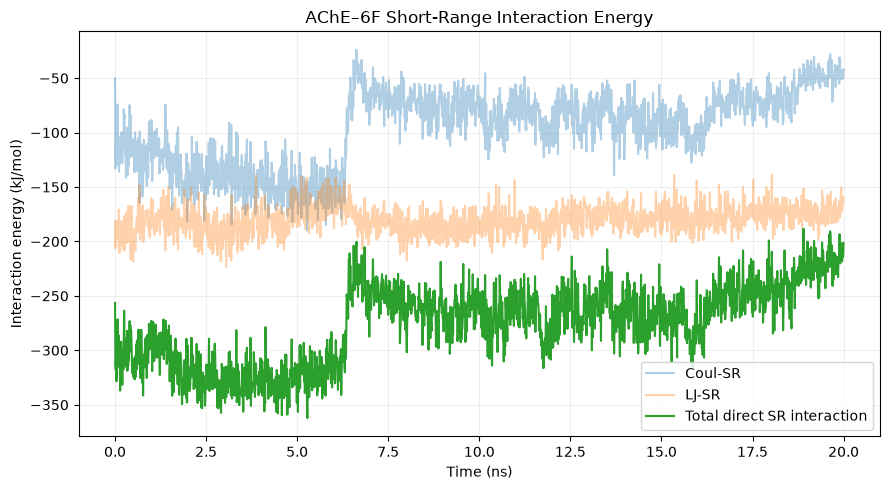

In [63]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(time_ns, coul_sr, alpha=0.35, label="Coul-SR")
ax.plot(time_ns, lj_sr, alpha=0.35, label="LJ-SR")
ax.plot(time_ns, total_ie, linewidth=1.5, label="Total direct SR interaction")

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Interaction energy (kJ/mol)")
ax.set_title("AChE–6F Short-Range Interaction Energy")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "results/figures/protein_6F_interaction_energy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

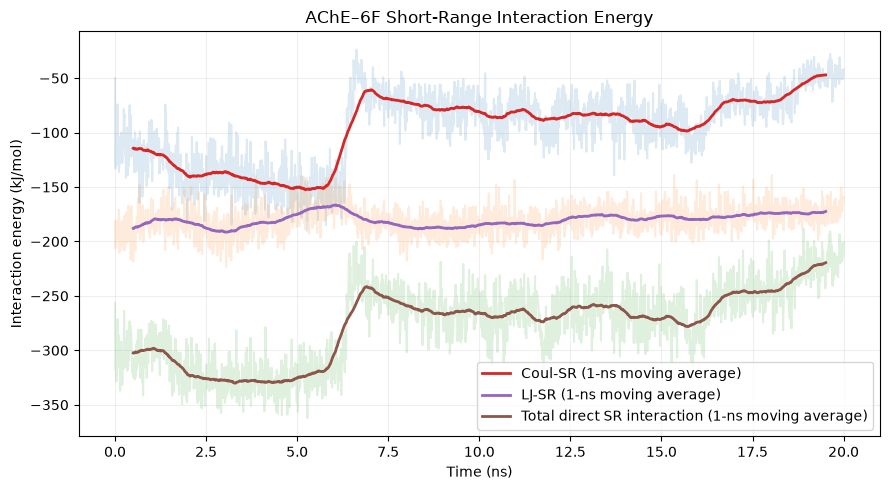

In [64]:
# 1-ns moving average
# trajectory interval = 0.01 ns, therefore 100 frames ≈ 1 ns
window = 100

coul_smooth = pd.Series(coul_sr).rolling(
    window=window, center=True
).mean()

lj_smooth = pd.Series(lj_sr).rolling(
    window=window, center=True
).mean()

total_smooth = pd.Series(total_ie).rolling(
    window=window, center=True
).mean()

fig, ax = plt.subplots(figsize=(9, 5))

# Raw data
ax.plot(time_ns, coul_sr, alpha=0.15)
ax.plot(time_ns, lj_sr, alpha=0.15)
ax.plot(time_ns, total_ie, alpha=0.15)

# 1-ns moving averages
ax.plot(
    time_ns, coul_smooth,
    linewidth=2,
    label="Coul-SR (1-ns moving average)"
)

ax.plot(
    time_ns, lj_smooth,
    linewidth=2,
    label="LJ-SR (1-ns moving average)"
)

ax.plot(
    time_ns, total_smooth,
    linewidth=2,
    label="Total direct SR interaction (1-ns moving average)"
)

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Interaction energy (kJ/mol)")
ax.set_title("AChE–6F Short-Range Interaction Energy")

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "results/figures/protein_6F_interaction_energy_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

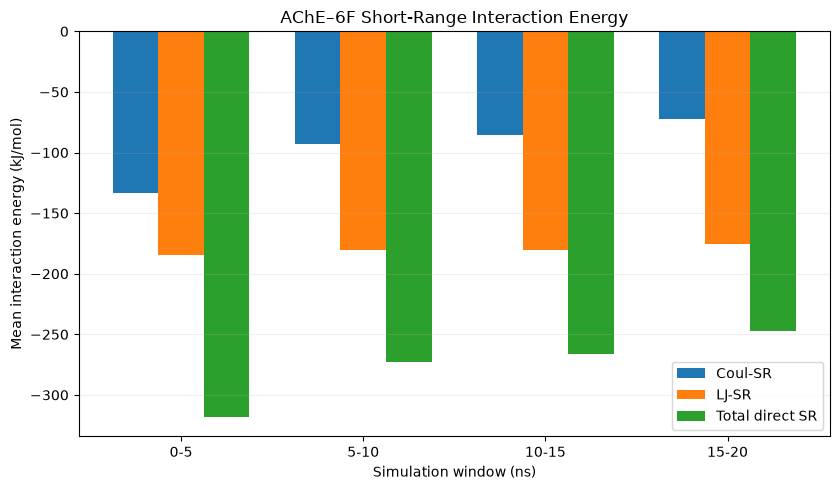

In [65]:
plot_df = ie_windows_df.copy()

x = np.arange(len(plot_df))
width = 0.25

fig, ax = plt.subplots(figsize=(8.5, 5))

ax.bar(
    x - width,
    plot_df["Coul-SR mean (kJ/mol)"],
    width,
    label="Coul-SR"
)

ax.bar(
    x,
    plot_df["LJ-SR mean (kJ/mol)"],
    width,
    label="LJ-SR"
)

ax.bar(
    x + width,
    plot_df["Total mean (kJ/mol)"],
    width,
    label="Total direct SR"
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Time window (ns)"])

ax.set_xlabel("Simulation window (ns)")
ax.set_ylabel("Mean interaction energy (kJ/mol)")
ax.set_title("AChE–6F Short-Range Interaction Energy")

ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig(
    "results/figures/protein_6F_interaction_energy_windows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
temp = np.loadtxt(
    "analysis/npt_temperature.xvg",
    comments=("@", "#")
)

press_density = np.loadtxt(
    "analysis/npt_pressure_density.xvg",
    comments=("@", "#")
)

print("Temperature shape:", temp.shape)
print("Pressure/density shape:", press_density.shape)

print("\nTemperature first rows:")
print(temp[:3])

print("\nPressure/density first rows:")
print(press_density[:3])

Temperature shape: (100, 2)
Pressure/density shape: (100, 3)

Temperature first rows:
[[  0.       299.434998]
 [  1.       300.834656]
 [  2.       298.792694]]

Pressure/density first rows:
[[ 0.00000000e+00 -3.67421051e+02  1.00919794e+03]
 [ 1.00000000e+00 -3.91406006e+02  1.01910156e+03]
 [ 2.00000000e+00 -1.16246552e+02  1.02404614e+03]]


In [67]:
temperature = temp[:, 1]

pressure = press_density[:, 1]
density = press_density[:, 2]

print("=== NPT Equilibration Statistics ===")

print("\nTemperature")
print(f"Mean = {temperature.mean():.2f} K")
print(f"SD   = {temperature.std():.2f} K")
print(f"Min  = {temperature.min():.2f} K")
print(f"Max  = {temperature.max():.2f} K")

print("\nPressure")
print(f"Mean = {pressure.mean():.2f} bar")
print(f"SD   = {pressure.std():.2f} bar")
print(f"Min  = {pressure.min():.2f} bar")
print(f"Max  = {pressure.max():.2f} bar")

print("\nDensity")
print(f"Mean = {density.mean():.2f} kg/m³")
print(f"SD   = {density.std():.2f} kg/m³")
print(f"Min  = {density.min():.2f} kg/m³")
print(f"Max  = {density.max():.2f} kg/m³")

=== NPT Equilibration Statistics ===

Temperature
Mean = 300.16 K
SD   = 0.99 K
Min  = 297.48 K
Max  = 302.25 K

Pressure
Mean = 2.88 bar
SD   = 125.92 bar
Min  = -393.27 bar
Max  = 272.24 bar

Density
Mean = 1033.45 kg/m³
SD   = 3.60 kg/m³
Min  = 1009.20 kg/m³
Max  = 1038.52 kg/m³


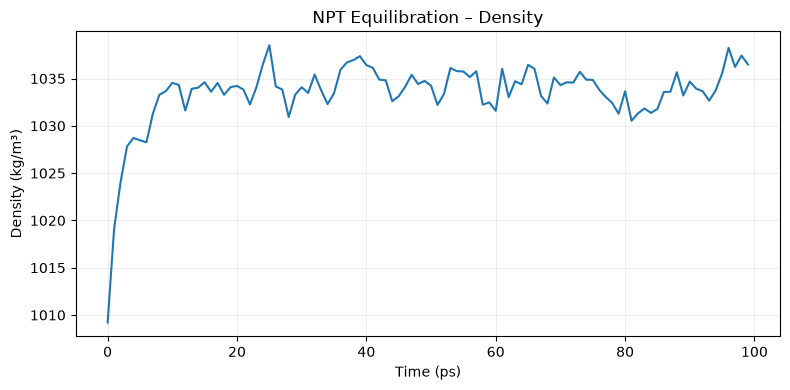

In [68]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(press_density[:, 0], density)

ax.set_xlabel("Time (ps)")
ax.set_ylabel("Density (kg/m³)")
ax.set_title("NPT Equilibration – Density")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

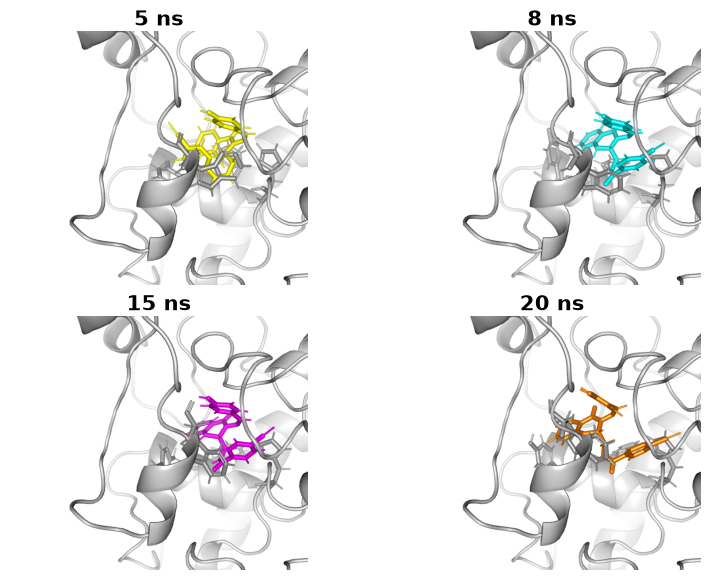

In [70]:
from PIL import Image
import matplotlib.pyplot as plt

snapshot_files = [
    ("5 ns",  "results/figures/snapshots/results_snapshot_5ns.png"),
    ("8 ns",  "results/figures/snapshots/results_snapshot_8ns.png"),
    ("15 ns", "results/figures/snapshots/results_snapshot_15ns.png"),
    ("20 ns", "results/figures/snapshots/results_snapshot_20ns.png"),
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 7),
    gridspec_kw={"wspace": 0.03, "hspace": 0.12}
)

for ax, (label, filename) in zip(axes.flat, snapshot_files):

    img = Image.open(filename)

    # Same crop applied to every snapshot
    img = img.crop((150, 40, 1100, 850))

    ax.imshow(img)
    ax.set_title(label, fontsize=15, fontweight="bold", pad=4)
    ax.axis("off")

plt.savefig(
    "results/figures/6F_binding_pose_evolution_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [71]:
summary_data = {
    "Metric": [
        "Protein backbone RMSD",
        "Protein Rg",
        "Ligand heavy-atom RMSD",
        "Protein–6F H-bonds",
        "Heavy-atom contacts",
        "Heavy-atom minimum distance",
        "Direct SR interaction energy"
    ],
    "Key result": [
        "Final ~0.190 nm; final 10 ns relatively stable around ~0.185 nm",
        "Final half ~2.318 nm with small fluctuations",
        "Final ~0.594 nm; major pose transitions during trajectory",
        "2.62 → 0.93 average H-bonds from first to last 5-ns window",
        "177.0 → 144.6 contacts from first to last 5-ns window",
        "0.270 → 0.300 nm from first to last 5-ns window",
        "-318.37 → -247.51 kJ/mol from first to last 5-ns window"
    ],
    "Interpretation": [
        "Protein backbone remained comparatively stable",
        "Overall protein compactness was maintained",
        "6F underwent substantial reorientation",
        "Polar interaction network decreased over time",
        "Packing/contact network was remodeled",
        "Ligand remained in close protein contact",
        "Short-range interaction regime changed, mainly electrostatically"
    ]
}

md_summary_df = pd.DataFrame(summary_data)

md_summary_df

,Metric,Key result,Interpretation
0,Protein backbone RMSD,Final ~0.190 nm; final 10 ns relatively stable...,Protein backbone remained comparatively stable
1,Protein Rg,Final half ~2.318 nm with small fluctuations,Overall protein compactness was maintained
2,Ligand heavy-atom RMSD,Final ~0.594 nm; major pose transitions during...,6F underwent substantial reorientation
3,Protein–6F H-bonds,2.62 → 0.93 average H-bonds from first to last...,Polar interaction network decreased over time
4,Heavy-atom contacts,177.0 → 144.6 contacts from first to last 5-ns...,Packing/contact network was remodeled
5,Heavy-atom minimum distance,0.270 → 0.300 nm from first to last 5-ns window,Ligand remained in close protein contact
6,Direct SR interaction energy,-318.37 → -247.51 kJ/mol from first to last 5-...,"Short-range interaction regime changed, mainly..."


In [72]:
md_summary_df.to_csv(
    "results/tables/MD_6F_final_summary.csv",
    index=False
)

print("Saved: results/tables/MD_6F_final_summary.csv")

Saved: results/tables/MD_6F_final_summary.csv
